In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [202]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
from sklearn.tree import plot_tree

# **Load and Inspect Data**

In [203]:
df = pd.read_csv('/content/heart_disease_uci.csv')

In [204]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (920, 16)

Columns: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

First 5 rows:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [206]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


# **Exploratory Data Analysis (EDA)**

Understanding the data through visualizations and statistics.

In [207]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


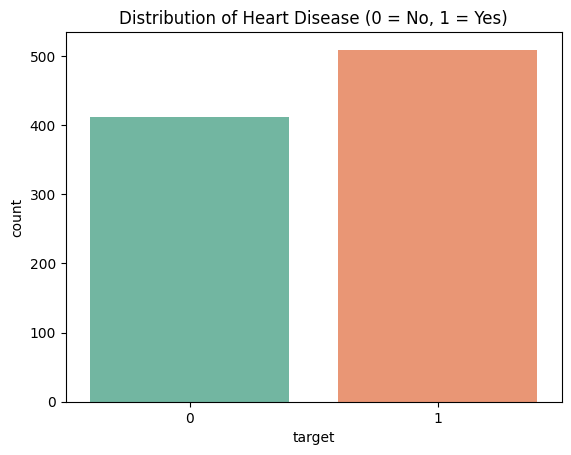

Percentage with heart disease: 55.326086956521735 %


In [208]:
df['target'] = (df['num'] > 0).astype(int)
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Distribution of Heart Disease (0 = No, 1 = Yes)')
plt.show()
print("Percentage with heart disease:", df['target'].mean()*100, "%")

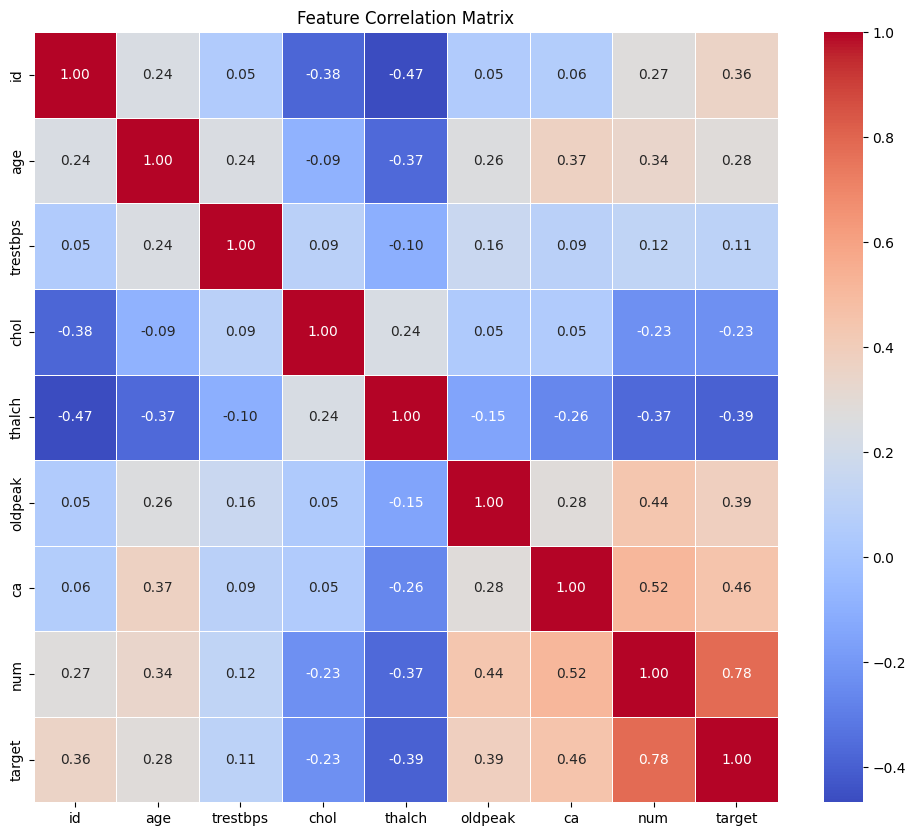

In [237]:
# Correlation heatmap to see relationships between numeric features
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

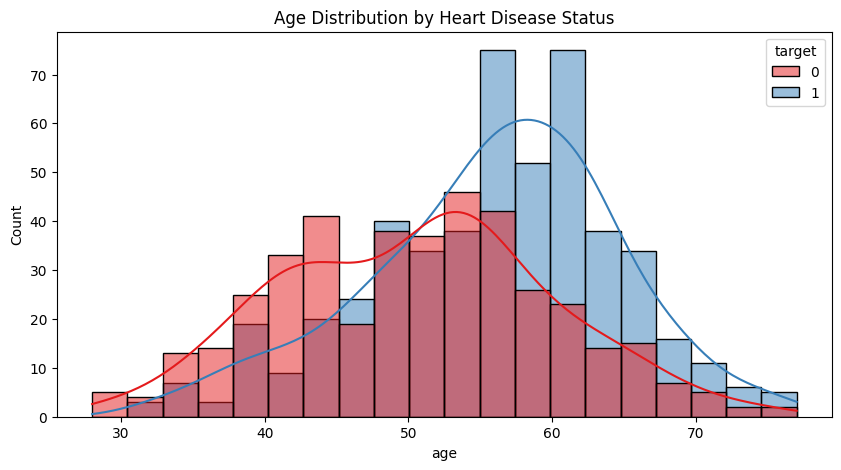

In [238]:
# Age distribution split by target
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='age', hue='target', kde=True, bins=20, palette='Set1')
plt.title('Age Distribution by Heart Disease Status')
plt.show()

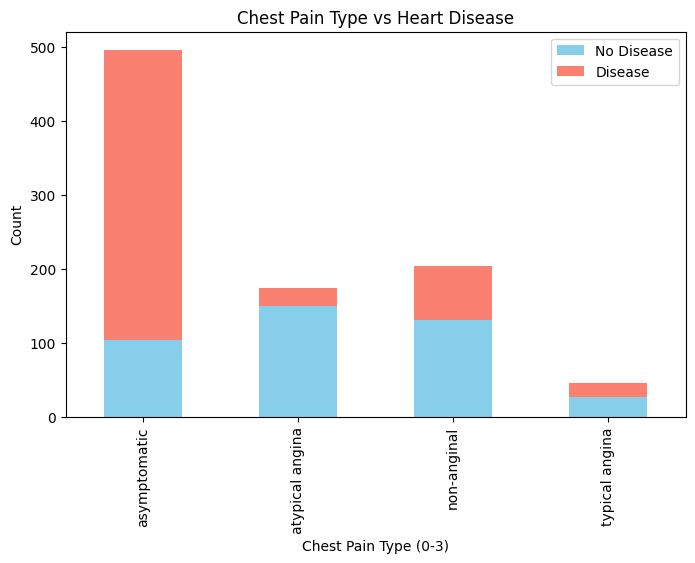

In [239]:
# Chest pain type (cp) vs heart disease – stacked bar chart
pd.crosstab(df['cp'], df['target']).plot(kind='bar', stacked=True, figsize=(8,5), color=['skyblue', 'salmon'])
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type (0-3)')
plt.ylabel('Count')
plt.legend(['No Disease', 'Disease'])
plt.show()

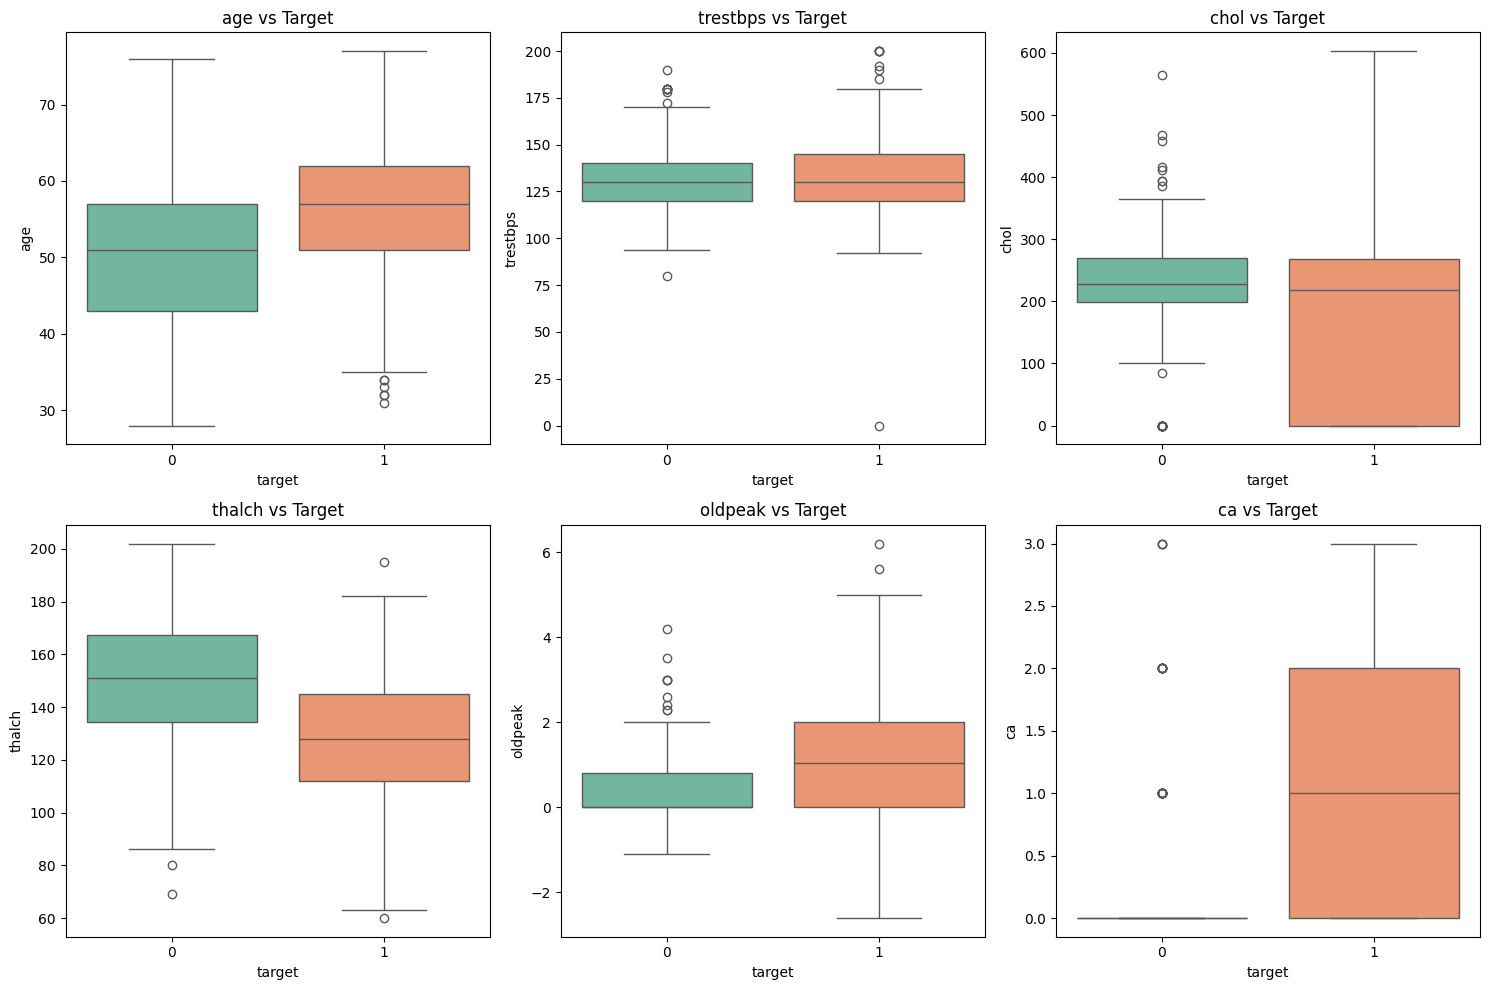

In [240]:
# Box plots to compare feature distributions across target classes
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca'] # Corrected 'thalach' to 'thalch'
for i, feat in enumerate(features):
    row, col = i // 3, i % 3
    sns.boxplot(x='target', y=feat, data=df, ax=axes[row, col], palette='Set2')
    axes[row, col].set_title(f'{feat} vs Target')
plt.tight_layout()
plt.show()

**Data Preprocessing**

In [213]:
X = df.drop(['target', 'num'], axis=1)
y = df['target']

In [214]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 736 samples
Test set size: 184 samples


In [215]:
X_train_processed = X_train.drop('id', axis=1)
X_test_processed = X_test.drop('id', axis=1)

In [216]:
numerical_cols = X_train_processed.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train_processed.select_dtypes(include='object').columns.tolist()

In [217]:
for col in numerical_cols:
    X_train_processed[col].fillna(X_train_processed[col].mean(), inplace=True)
    X_test_processed[col].fillna(X_train_processed[col].mean(), inplace=True)

In [218]:
for col in categorical_cols:
    X_train_processed[col].fillna(X_train_processed[col].mode()[0], inplace=True)
    X_test_processed[col].fillna(X_train_processed[col].mode()[0], inplace=True)

In [219]:
X_train_processed = pd.get_dummies(X_train_processed, columns=categorical_cols, drop_first=True, dtype=int)
X_test_processed = pd.get_dummies(X_test_processed, columns=categorical_cols, drop_first=True, dtype=int)

In [220]:
train_cols = X_train_processed.columns
test_cols = X_test_processed.columns

In [221]:
missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test_processed[c] = 0

In [222]:
missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train_processed[c] = 0

In [223]:
X_test_processed = X_test_processed[train_cols]

In [224]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

In [225]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_processed.columns, index=X_train_processed.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_processed.columns, index=X_test_processed.index)

# **Evaluation Function**

In [226]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"=== {model_name} ===")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_test_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # ROC Curve if probabilities available
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
        plt.plot([0,1], [0,1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{model_name} - ROC Curve')
        plt.legend()
        plt.show()

    return test_acc

# **Model Training**

# Model 1: Logistic Regression

In [227]:
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

# Model 2: Decision Tree (with limited depth to avoid overfitting)

In [228]:
dtree = DecisionTreeClassifier(random_state=42, max_depth=5)
dtree.fit(X_train_processed, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

# **Model Evaluation**

=== Logistic Regression ===
Training Accuracy: 0.8397
Test Accuracy: 0.8424

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.85      0.78      0.82        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



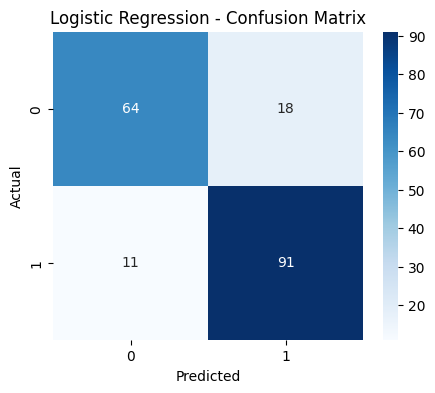

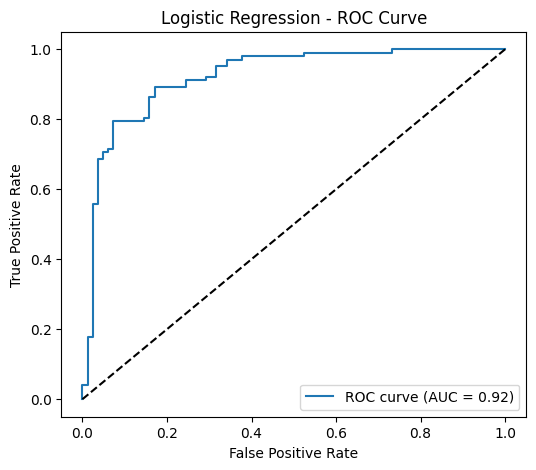

In [229]:
logreg_acc = evaluate_model(logreg, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression")

=== Decision Tree ===
Training Accuracy: 0.8193
Test Accuracy: 0.7989

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.78      0.77      0.77        82
           1       0.82      0.82      0.82       102

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.80      0.80      0.80       184



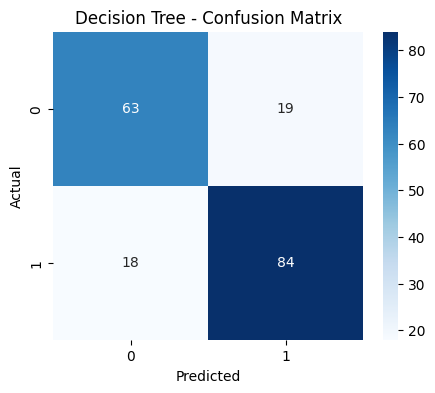

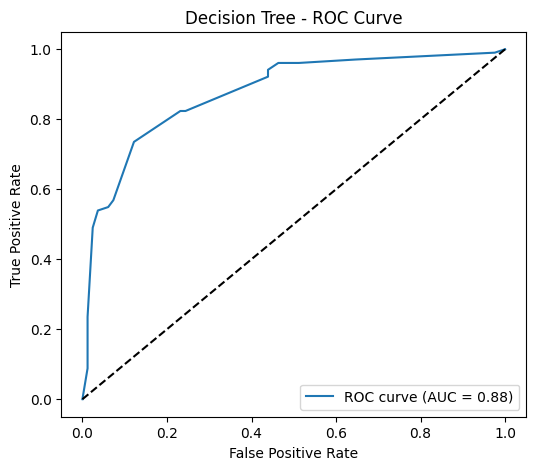

In [230]:
dtree_acc = evaluate_model(dtree, X_train_processed, X_test_processed, y_train, y_test, "Decision Tree")

# **Feature Importance**

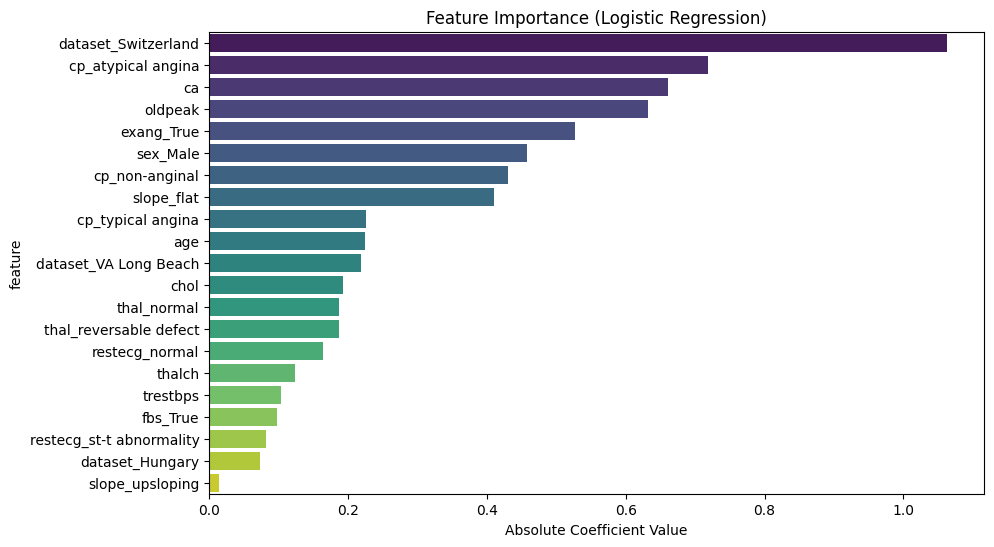

Top 5 most important features (Logistic Regression):
                feature  coefficient
8   dataset_Switzerland     1.063178
10   cp_atypical angina    -0.718150
5                    ca     0.661181
4               oldpeak     0.632749
16           exang_True     0.527355


In [231]:
coef_importance = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': logreg.coef_[0],
    'abs_coef': np.abs(logreg.coef_[0])
}).sort_values('abs_coef', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='abs_coef', y='feature', data=coef_importance, palette='viridis')
plt.title('Feature Importance (Logistic Regression)')
plt.xlabel('Absolute Coefficient Value')
plt.show()

print("Top 5 most important features (Logistic Regression):")
print(coef_importance[['feature', 'coefficient']].head())

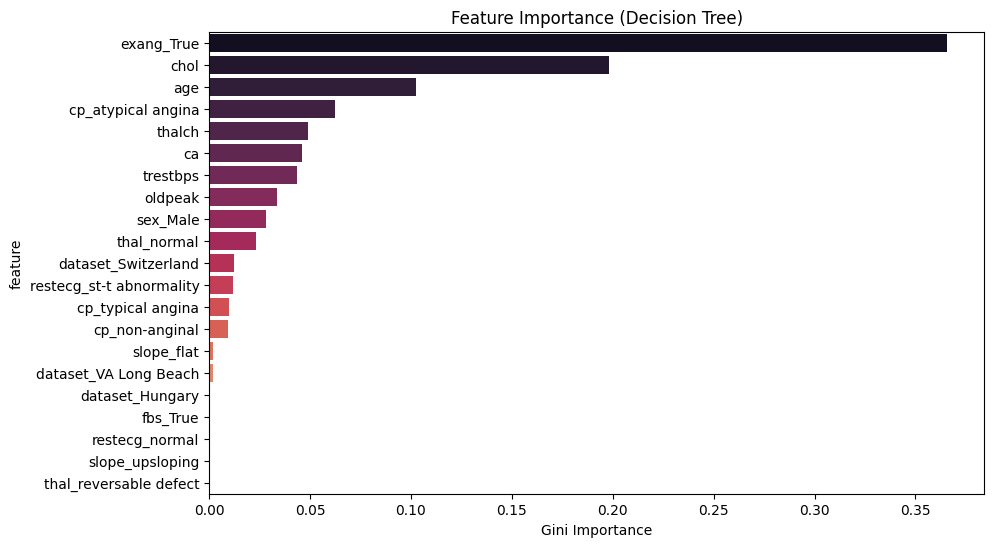

Top 5 most important features (Decision Tree):
               feature  importance
16          exang_True    0.365763
2                 chol    0.198283
0                  age    0.102706
10  cp_atypical angina    0.062433
3               thalch    0.049078


In [233]:
tree_importance = pd.DataFrame({
    'feature': X_train_processed.columns,
    'importance': dtree.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=tree_importance, palette='rocket')
plt.title('Feature Importance (Decision Tree)')
plt.xlabel('Gini Importance')
plt.show()

print("Top 5 most important features (Decision Tree):")
print(tree_importance.head())

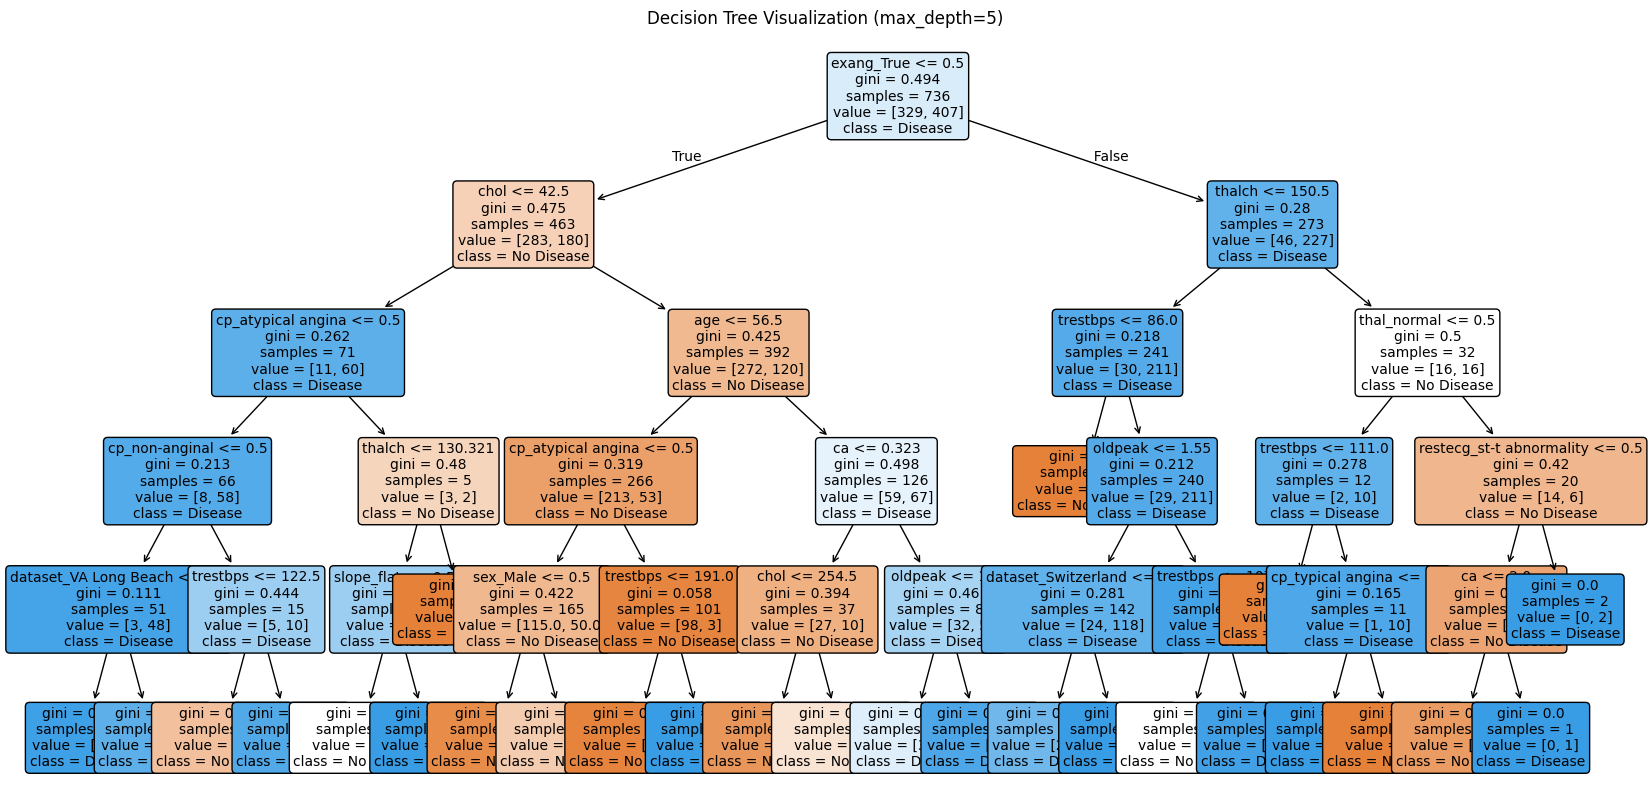

In [235]:
plt.figure(figsize=(20,10))
plot_tree(dtree, feature_names=X_train_processed.columns, class_names=['No Disease', 'Disease'], filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Visualization (max_depth=5)')
plt.show()

# **Final Comparison and Insights**

In [236]:
# %%
print("="*50)
print("FINAL MODEL COMPARISON")
print("="*50)
print(f"Logistic Regression Test Accuracy: {logreg_acc:.4f}")
print(f"Decision Tree Test Accuracy: {dtree_acc:.4f}")

if logreg_acc > dtree_acc:
    print("\n✅ Logistic Regression performs better on test data.")
else:
    print("\n✅ Decision Tree performs better on test data.")

FINAL MODEL COMPARISON
Logistic Regression Test Accuracy: 0.8424
Decision Tree Test Accuracy: 0.7989

✅ Logistic Regression performs better on test data.


# **Key Insights**
- The most important features across both models include chest pain type (`cp`), maximum heart rate (`thalch`), number of major vessels (`ca`), and ST depression (`oldpeak`).
- Logistic Regression provides a linear, interpretable model with good generalization.
- Decision Tree captures non-linear relationships but risks overfitting if not pruned.
- The ROC-AUC scores (>0.85) indicate strong discriminative ability.